# GreenHouse — весь калькулятор в одном ноутбуке

Разбор кейса «завод в Йемене»: проверка вендорского предложения
(1500 kWp PV / 3132 kWh BESS / 1000 kW DG), поиск оптимальных размеров
и анализ чувствительности.

**Как пользоваться:** запусти все ячейки сверху вниз (Run All), полный
прогон ~3–4 минуты. Перед каждой ячейкой — что мы делаем; после — разбор
терминов: что это и зачем оно нам.

**Графики:** по умолчанию статичные — они отрисовываются в любом
окружении. Хочешь zoom/pan — поставь `INTERACTIVE = True` в ячейке
блока 1 и перезапусти ноутбук (если вместо графика появится
«Could not render...», твоя среда не дружит с ipympl — верни False).

## 0. Проверка ядра (kernel)

Ноутбук обязан работать в окружении проекта `.venv` — там установлены все
библиотеки. Если выбрано чужое ядро, ячейка ниже остановится с инструкцией
вместо загадочной ошибки на середине.

In [1]:
# Предохранитель: то ли ядро выбрано? (частая ошибка — системный Python)
import sys

print("Python этого ядра:", sys.executable)
try:
    import pydantic  # noqa: F401 — маркер: библиотеки проекта на месте
    print("Ядро правильное — можно работать.")
except ModuleNotFoundError:
    raise RuntimeError(
        "Выбрано НЕ то ядро. Вверху справа: Select Kernel -> "
        "Jupyter Kernel... -> 'Python (GreenHouse .venv)' — и Run All заново."
    ) from None

Python этого ядра: d:\Greenhouse\.venv\Scripts\python.exe
Ядро правильное — можно работать.


#### 📖 Термины этого блока

- **Ядро (kernel)** — процесс Python, который исполняет ячейки ноутбука.
  Ноутбук — только текст; считает ядро. *Зачем нам:* выбрать ядро из `.venv`
  проекта, иначе не найдутся наши библиотеки (та самая ошибка
  `No module named 'pydantic'`).
- **Виртуальное окружение (venv)** — изолированная папка с Python и точным
  набором библиотек проекта. *Зачем нам:* расчёты воспроизводимы и не зависят
  от того, что установлено в системе.

## 1. Подготовка: интерактивные графики и импорты

Включаем zoom/pan, импортируем слои калькулятора и закрепляем цвета:
жёлтый — солнце, зелёный — батарея, красный — дизель. Один цвет = одна
технология во всех графиках ноутбука.

In [2]:
# Режим графиков. INTERACTIVE = True даёт zoom/pan (ipympl), но
# требует, чтобы твой редактор умел рендерить jupyter-виджеты; если
# видишь "Could not render content..." — верни False: статичные
# картинки (inline) работают везде.
INTERACTIVE = False

if INTERACTIVE:
    get_ipython().run_line_magic("matplotlib", "widget")
    print("Интерактив включён: колесо/рамка = zoom, крестовина = pan.")
else:
    get_ipython().run_line_magic("matplotlib", "inline")
    print("Статичные графики (надёжный режим). Zoom: INTERACTIVE = True.")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path().resolve()))  # корень проекта в путях импорта

from src.schema import Scenario
from src.profiles import build_load_profile, timestep_hours
from src.solar import build_solar_profile
from src.simulate import run_simulation
from src.kpi import compute_kpi
from src.economics import compute_economics
from src.optimize import optimize_dispatch, optimize_sizing
from src.sweep import run_sensitivity

sns.set_theme(style="whitegrid", context="notebook")
C_PV, C_BESS, C_DG = "#eda100", "#1baf7a", "#e34948"   # солнце / батарея / дизель
C_BLUE, C_BLUE_LIGHT, INK = "#2a78d6", "#9ec5f4", "#0b0b0b"

WEATHER = "tests/data/tmy_sanaa_pvgis_sarah3.csv"  # кэш погоды — интернет не нужен
print("Импорты готовы.")

Статичные графики (надёжный режим). Zoom: INTERACTIVE = True.
Импорты готовы.


#### 📖 Термины этого блока

- **ipympl / backend** — «движок вывода» matplotlib. Backend `widget`
  рисует график как интерактивный элемент. *Зачем нам:* приближать часы и
  дни на годовых рядах, не перестраивая график.
- **seaborn** — надстройка над matplotlib: аккуратный стиль и короткий код
  графиков. *Зачем нам:* меньше строк — меньше места для ошибок.
- **Кэш погоды** — заранее скачанный файл с погодным годом. *Зачем нам:*
  ноутбук работает офлайн и всегда даёт одинаковые числа.

## 2. Входной сценарий — контракт данных

Весь проект — один JSON-файл. Схема (`src/schema.py`) проверяет его на
входе: типы, границы, взаимоисключающие режимы — мусор останавливается до
расчёта. Файла два: `yemen_vendor.json` (размеры зафиксированы — проверка
вендора) и `yemen_sizing.json` (коридоры открыты — поиск оптимума).

Источник чисел — вендорский PDF «Microgrid system solution for factories
in Yemen». Ниже две таблицы: что из документа ЖИВЁТ В МОДЕЛИ, и что
осталось В ДОКУМЕНТЕ (контекст и сознательно исключённое из v1).

In [3]:
vendor = Scenario.model_validate(
    json.load(open("scenarios/yemen_vendor.json", encoding="utf-8")))
sizing_scenario = Scenario.model_validate(
    json.load(open("scenarios/yemen_sizing.json", encoding="utf-8")))

print("=== В МОДЕЛИ (из сценария, проверено схемой) ===")
display(pd.DataFrame([
    ["Площадка", f"{vendor.site.latitude}N, {vendor.site.longitude}E ({vendor.site.timezone})"],
    ["PV (вендор), kWp", f"{vendor.pv.max_kw} (панель {vendor.pv.unit_kw} kWp)"],
    ["BESS, kWh", f"{vendor.battery.max_kwh} (шкаф {vendor.battery.unit_kwh} kWh, LFP)"],
    ["BESS (PCS), kW", f"{vendor.battery.max_kw} (PCS {vendor.battery.unit_kw} kW; "
                       "в PDF разделы противоречат друг другу — см. разбор ниже)"],
    ["DG, kW", f"{vendor.diesel.max_kw} (контейнерный, PRP)"],
    ["Нагрузка день/ночь, kW", f"{vendor.load.day_kw} / {vendor.load.night_kw} "
                               f"(смена {vendor.load.work_start_hour}-{vendor.load.work_end_hour})"],
    ["RTE батареи / пол SOC", f"{vendor.battery.rte_fraction} / {vendor.battery.soc_min_fraction:.0%}"],
    ["Дизельный kWh, $", vendor.diesel.fuel_cost_usd_per_kwh],
    ["Ставка / горизонт", f"{vendor.financial.discount_rate_fraction:.0%} / "
                          f"{vendor.financial.project_years} лет"],
    ["Крыша (сайзинг), м2", sizing_scenario.site.roof_area_m2],
], columns=["параметр", "значение"]))

print("=== В ДОКУМЕНТЕ, но ВНЕ модели v1 (контекст и исключённое) ===")
display(pd.DataFrame([
    ["Состав нагрузки", "кондиционирование 200 kW + компрессор 200 kW + "
                        "линия розлива ~300 kW + PLC/сервоприводы",
     "суммарные 650-700 kW уже в профиле; поминутные пуски — вне Δt=1ч"],
    ["Суточное потребление", ">= 7000 kWh (PDF, 1.2)",
     "наш профиль даёт 7700 (с ночной базой 50 kW) — согласуется"],
    ["PR системы", "82% (PDF, 1.4)",
     "мы считаем потери сами (консервативнее) — отсюда разница с "
     "вендорскими ~7500 kWh/день"],
    ["Наклон панелей", "~15 градусов (PDF, 2.3)",
     "в модели ASSUMPTION 20 (дефолт REopt) — кандидат на правку!"],
    ["Деградация PV / SOH BESS", "<=8% за 10 лет / >=85% за 10 лет",
     "не моделируем (вне scope v1); подтверждает срок жизни батареи 10 лет"],
    ["DVR 800 kW / 375 kWh", "динамический восстановитель напряжения, "
                             "<=5 мс, до 20 минут",
     "качество энергии = миллисекунды = firmware, НЕ энергобаланс часа"],
    ["Grid-forming PCS, SCADA, +-5%", "требования качества (PDF, 1.3)",
     "вне LP-модели по той же причине"],
    ["Трансформатор 1000 kVA, свой DG 800 kW", "планы завода (PDF, 1.2)",
     "контекст; в микрогриде вендора дизель 1000 kW"],
    ["Утренний резерв SOC >= 30%", "правило EMS в 7:45 (PDF, 8.2)",
     "операционное правило; наш пол SOC 20% — статический аналог"],
], columns=["факт из PDF", "значение", "почему (не) в модели"]))

=== В МОДЕЛИ (из сценария, проверено схемой) ===


,параметр,значение
0,Площадка,"15.2811N, 44.0811E (Asia/Aden)"
1,"PV (вендор), kWp",1500.0 (панель 0.58 kWp)
2,"BESS, kWh","3132.0 (шкаф 261.0 kWh, LFP)"
3,"BESS (PCS), kW",1500.0 (PCS 125.0 kW; в PDF разделы противореч...
4,"DG, kW","1000.0 (контейнерный, PRP)"
5,"Нагрузка день/ночь, kW",700.0 / 50.0 (смена 8-18)
6,RTE батареи / пол SOC,0.85 / 20%
7,"Дизельный kWh, $",0.26
8,Ставка / горизонт,8% / 10 лет
9,"Крыша (сайзинг), м2",8500.0


=== В ДОКУМЕНТЕ, но ВНЕ модели v1 (контекст и исключённое) ===


,факт из PDF,значение,почему (не) в модели
0,Состав нагрузки,кондиционирование 200 kW + компрессор 200 kW +...,суммарные 650-700 kW уже в профиле; поминутные...
1,Суточное потребление,">= 7000 kWh (PDF, 1.2)",наш профиль даёт 7700 (с ночной базой 50 kW) —...
2,PR системы,"82% (PDF, 1.4)",мы считаем потери сами (консервативнее) — отсю...
3,Наклон панелей,"~15 градусов (PDF, 2.3)",в модели ASSUMPTION 20 (дефолт REopt) — кандид...
4,Деградация PV / SOH BESS,<=8% за 10 лет / >=85% за 10 лет,не моделируем (вне scope v1); подтверждает сро...
5,DVR 800 kW / 375 kWh,"динамический восстановитель напряжения, <=5 мс...","качество энергии = миллисекунды = firmware, НЕ..."
6,"Grid-forming PCS, SCADA, +-5%","требования качества (PDF, 1.3)",вне LP-модели по той же причине
7,"Трансформатор 1000 kVA, свой DG 800 kW","планы завода (PDF, 1.2)",контекст; в микрогриде вендора дизель 1000 kW
8,Утренний резерв SOC >= 30%,"правило EMS в 7:45 (PDF, 8.2)",операционное правило; наш пол SOC 20% — статич...


#### 📖 Термины этого блока

- **kW (киловатт)** — МОЩНОСТЬ: скорость потока энергии прямо сейчас.
  **kWh (киловатт-час)** — ЭНЕРГИЯ: количество (мощность × время).
  **kWp (киловатт-пик)** — паспортная мощность солнечных панелей при
  идеальных условиях; реальная выработка всегда ниже. *Зачем различать:*
  батарею описывают ДВА числа — kWh (сколько хранит) и kW (как быстро
  отдаёт), и путаница между ними — ошибка №1 в энергетике.
- **PV / BESS / DG** — солнечные панели (photovoltaics) / накопитель
  (battery energy storage system) / дизель-генератор (diesel generator).
- **CAPEX** — разовые капитальные затраты (купить и смонтировать).
  **O&M** — ежегодная эксплуатация и обслуживание. *Зачем нам:* это две
  разные статьи денег; сравнивать их напрямую нельзя (см. CRF в блоке 6).
- **Ставка дисконтирования** — насколько «деньги сегодня» ценнее «денег
  через год» (у нас 8%). *Зачем нам:* честно складывать затраты разных лет.
- **Коридор min/max** — допустимый диапазон размера технологии:
  min == max — размер зафиксирован; min < max — выбирает оптимизатор.
- **PCS (power conversion system)** — двунаправленный преобразователь
  батареи (DC↔AC); его kW — «скорость» батареи. *Найденное противоречие
  PDF:* раздел 2.1 говорит «2 PCS суммарно 750 kW», разделы 4.3 и 9.2 и
  все схемы — «12 × 125 kW = 1500 kW». Мы берём 1500 (12 шкафов физически
  несут 12 PCS), но это готовый вопрос вендору. *Зачем нам такой разбор:*
  модель заставляет противоречия документа всплыть — уже польза.
- **PR (performance ratio)** — доля теоретической выработки, дошедшая до
  потребителя после всех потерь. Вендор обещает 82%; мы потери считаем
  сами и консервативнее (песок 5%, жара) — поэтому наша PV-выработка ниже
  вендорской. *Зачем нам:* понимать источник расхождения с рекламой.
- **DVR (dynamic voltage restorer)** — «чистильщик» напряжения для
  чувствительной нагрузки (миллисекунды, до 20 минут поддержки). *Почему
  вне модели:* качество энергии — задача firmware и теории управления, а
  не часового энергобаланса; его 375 kWh — не сдвиг энергии, а страховка.

## 3. Профиль нагрузки

Синтетический годовой ряд: 700 kW в рабочие часы (08–18), 50 kW ночью —
7700 kWh в сутки. Ключевой инвариант проекта: длительность шага **Δt
читается из данных**, а энергия всегда = мощность × Δt — поэтому те же
модули работают с часовыми, 15-минутными и суточными рядами.

шагов: 8760 | Δt = 1.0 ч | энергия года = 2,810,500 kWh


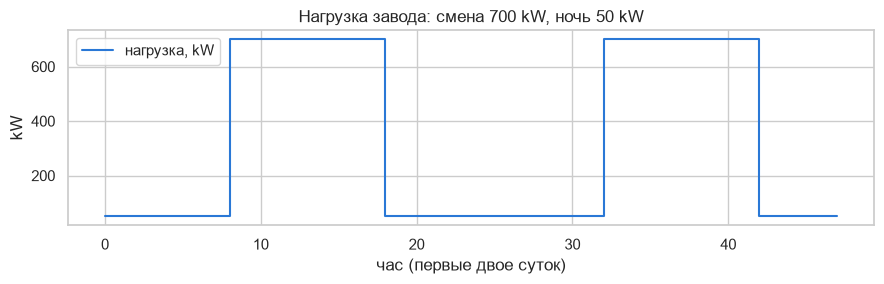

In [4]:
load = build_load_profile(vendor)
dt = timestep_hours(load)
print(f"шагов: {len(load)} | Δt = {dt} ч | энергия года = {load.sum()*dt:,.0f} kWh")

two_days = load.iloc[:48]
fig, ax = plt.subplots(figsize=(9, 3))
sns.lineplot(x=range(48), y=two_days.values, drawstyle="steps-post",
             color=C_BLUE, ax=ax, label="нагрузка, kW")
ax.set(xlabel="час (первые двое суток)", ylabel="kW",
       title="Нагрузка завода: смена 700 kW, ночь 50 kW")
ax.legend()
plt.tight_layout()

#### 📖 Термины этого блока

- **Профиль нагрузки** — временной ряд «сколько kW потребляет объект в
  каждый момент». *Зачем нам:* это спрос, под который подбирается всё
  оборудование.
- **Δt (timestep)** — длительность одного шага ряда, в часах. *Зачем нам:*
  формула энергии E = P × Δt; если молча считать «шаг = час» на суточных
  данных, энергия занизится в 24 раза — самый коварный класс ошибок.
- **Синтетический профиль** — построенный по правилу (день/ночь), а не из
  измерений. *Зачем нам:* у завода ещё нет счётчиков с историей; правило
  честно записано в сценарии и легко заменяется на CSV с реальными данными.

## 4. Солнце: типичный год (TMY) и модель PVWatts

Погода — спутниковая база PVGIS SARAH3; из архива 2005–2023 склеен
«типичный год». Модель PVWatts (стандарт NREL) превращает облучённость в
kW на 1 kWp панелей: положение солнца → пересчёт на наклонную плоскость →
температурные потери → именованные потери (песок 5%!) → инвертор.

годовая удельная выработка: 1,502 kWh/kWp | средние сутки 4.11 kWh/kWp


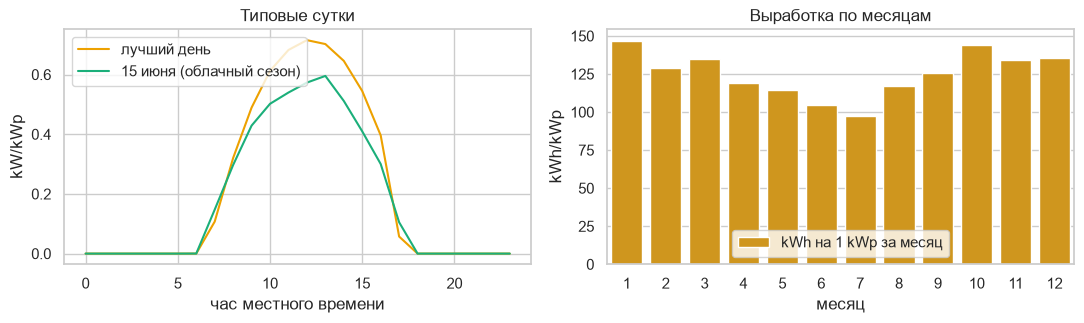

In [5]:
solar = build_solar_profile(vendor, weather_csv=WEATHER)
daily = solar.resample("D").sum()
print(f"годовая удельная выработка: {solar.sum():,.0f} kWh/kWp | "
      f"средние сутки {daily.mean():.2f} kWh/kWp")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
for day, color, label in ((str(daily.idxmax().date()), C_PV, "лучший день"),
                          ("2026-06-15", C_BESS, "15 июня (облачный сезон)")):
    d = solar[day]
    sns.lineplot(x=d.index.hour, y=d.values, ax=ax1, color=color, label=label)
ax1.set(xlabel="час местного времени", ylabel="kW/kWp", title="Типовые сутки")
ax1.legend()

monthly = solar.resample("MS").sum()
sns.barplot(x=list(range(1, 13)), y=monthly.values, ax=ax2,
            color=C_PV, label="kWh на 1 kWp за месяц")
ax2.set(xlabel="месяц", ylabel="kWh/kWp", title="Выработка по месяцам")
ax2.legend(loc="lower center")
plt.tight_layout()

#### 📖 Термины этого блока

- **TMY (Typical Meteorological Year)** — «типичный год»: для каждого
  календарного месяца из многолетнего архива выбран самый характерный
  реальный месяц, и из 12 таких месяцев склеен один год. *Зачем нам:*
  считать «как бывает обычно», а не «как было в конкретном году».
- **GHI / DNI / DHI** — три компоненты солнечной облучённости (Вт/м²):
  вся энергия на горизонтальную площадку / только прямые лучи / только
  рассеянный свет неба. *Зачем нам:* панель наклонена, и пересчёт на её
  плоскость требует всех трёх компонент по отдельности.
- **Удельная выработка (kW/kWp)** — сколько выдаёт 1 kWp установленной
  мощности. *Зачем нам:* размер системы становится простым множителем —
  ключ к быстрой оптимизации (у REopt это «production factor»).
- **Soiling** — загрязнение панелей (у нас песок → потери 5%).
  **Температурный derate** — потеря ~0.47% мощности на каждый °C нагрева
  ячейки выше 25 °C. *Зачем нам:* Йемен — жара и пыль, игнорировать их
  значит обещать заказчику лишние киловатты.
- Заметь на правом графике: **зима солнечнее лета** — июльская облачность
  над нагорьем Саны. Худший сезон солнца совпадает с круглогодичной
  нагрузкой — это и гоняет дизель летом.

## 5. Симуляция года: правило приоритета

`src/simulate.py` сводит энергобаланс каждого часа по жёсткому правилу:
PV → нагрузка; избыток → заряд батареи; остаток → сброс; дефицит →
разряд; затем дизель; что осталось — недопоставка. Баланс проверяется
assert-ом на каждом из 8760 шагов (±10⁻⁶ kW).

load: 2,810,500 kWh | pv_gen: 2,252,902 kWh | discharge: 317,396 kWh | dg: 611,915 kWh | curtail: 1,024 kWh | shortfall: 0 kWh


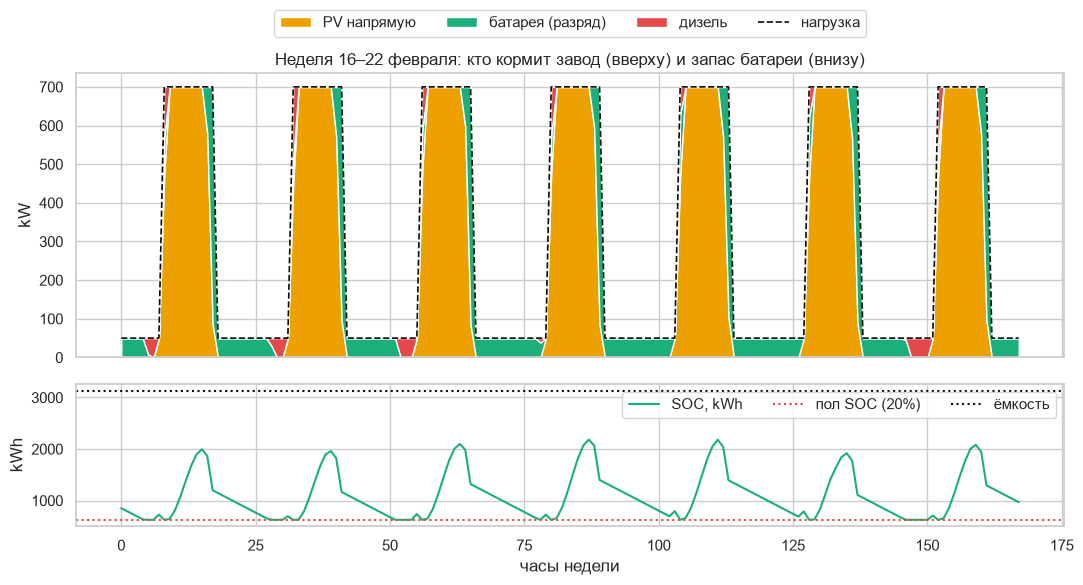

In [6]:
sim = run_simulation(vendor, weather_csv=WEATHER, write_outputs=False)
tot = sim.manifest["totals_kwh"]
print(" | ".join(f"{k}: {v:,.0f} kWh" for k, v in tot.items()))

week = sim.table.loc["2026-02-16":"2026-02-22"]
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                              height_ratios=[2, 1])
ax.stackplot(range(len(week)), week.pv_to_load_kw, week.discharge_kw, week.dg_kw,
             colors=[C_PV, C_BESS, C_DG],
             labels=["PV напрямую", "батарея (разряд)", "дизель"])
ax.plot(range(len(week)), week.load_kw, "--", color=INK, lw=1.2, label="нагрузка")
ax.set(ylabel="kW", title="Неделя 16–22 февраля: кто кормит завод (вверху) "
                          "и запас батареи (внизу)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.25))

sns.lineplot(x=range(len(week)), y=week.soc_kwh.values, ax=ax2,
             color=C_BESS, label="SOC, kWh")
ax2.axhline(vendor.battery.soc_min_fraction * vendor.battery.max_kwh,
            ls=":", color=C_DG, label="пол SOC (20%)")
ax2.axhline(vendor.battery.max_kwh, ls=":", color=INK, label="ёмкость")
ax2.set(xlabel="часы недели", ylabel="kWh")
ax2.legend(ncol=3, loc="upper right")
plt.tight_layout()

#### 📖 Термины этого блока

- **Dispatch (диспетчеризация)** — логика «кто работает в этот час».
  Здесь — жёсткое правило приоритета; в блоке 7 его заменит оптимизатор.
  *Зачем нам:* проверить ЗАДАННУЮ конфигурацию, как это делает HOMER.
- **SOC (state of charge)** — запас энергии в батарее, kWh (нижний график).
  Ниже «пола» (20% ёмкости) не разряжаем — бережём ресурс ячеек. *Зачем
  нам:* весь суточный ритм системы виден именно в SOC: днём копим, вечером
  тратим, к рассвету — пол и старт дизеля.
- **RTE (round-trip efficiency)** — КПД полного цикла «зарядил-разрядил»
  (у нас 0.85): из 100 kWh обратно выйдет 85. В модели потери делятся
  поровну: η_заряда = η_разряда = √RTE ≈ 0.922 (приём REopt).
- **Curtailment** — принудительный сброс лишней выработки: батарея полна,
  нагрузка сыта, энергию некуда деть. *Зачем нам:* это не «ошибка», а
  нормальная цена дешёвых панелей.
- **Shortfall (недопоставка)** — спрос, который не покрыл никто. *Зачем
  нам:* главный сигнал «конфигурация не тянет».
- **Энергобаланс** — на каждом шаге приход == расход (± 10⁻⁶ kW):
  `PV + разряд + дизель + недопоставка == нагрузка + заряд + сброс`.
  *Зачем нам:* физика не прощает; любая дырка в балансе — баг модели.

## 6. KPI и экономика

`src/kpi.py` — технические итоги года, `src/economics.py` — деньги.
Мост между разовой покупкой и ежегодной соляркой — формула CRF.

,метрика,значение
0,LPSP (недопоставка),0.0%
1,Renewable fraction,78.2%
2,Дизель за год,"611,915 kWh за 5,592 ч ($159,098)"
3,CAPEX,"$1,517,872"
4,Годовые издержки,"$371,042"
5,"NPC (10 лет, 8%)","$2,489,720"
6,LCOE,$0.1320/kWh (чистый дизель: ~$0.276)
7,Окупаемость vs 100% дизель,2.8 лет


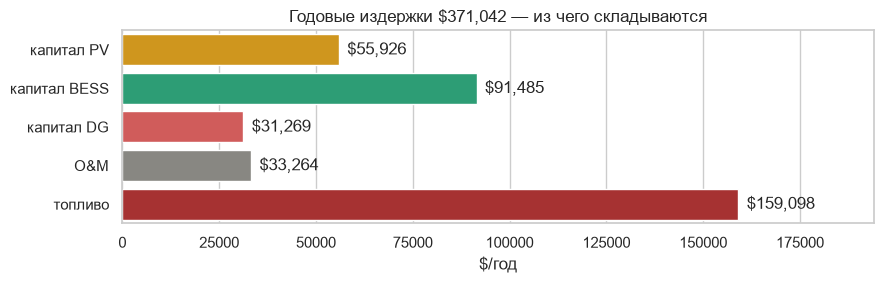

In [7]:
kpi = compute_kpi(vendor, sim)
eco = compute_economics(vendor, sim)

display(pd.DataFrame([
    ["LPSP (недопоставка)", f"{kpi.lpsp:.1%}"],
    ["Renewable fraction", f"{kpi.renewable_fraction:.1%}"],
    ["Дизель за год", f"{kpi.dg_kwh:,.0f} kWh за {kpi.dg_hours:,.0f} ч (${kpi.dg_fuel_usd:,.0f})"],
    ["CAPEX", f"${eco.capex_total_usd:,.0f}"],
    ["Годовые издержки", f"${eco.annual_cost_usd:,.0f}"],
    ["NPC (10 лет, 8%)", f"${eco.npc_usd:,.0f}"],
    ["LCOE", f"${eco.lcoe_usd_per_kwh:.4f}/kWh (чистый дизель: ~$0.276)"],
    ["Окупаемость vs 100% дизель", f"{eco.simple_payback_years:.1f} лет"],
], columns=["метрика", "значение"]))

# Структура годовых издержек: видно, кто ест деньги.
items = pd.DataFrame({
    "статья": ["капитал PV", "капитал BESS", "капитал DG", "O&M", "топливо"],
    "usd": [eco.by_tech["pv"].annualized_capex_usd,
            eco.by_tech["battery"].annualized_capex_usd,
            eco.by_tech["diesel"].annualized_capex_usd,
            eco.om_usd_per_year, eco.fuel_usd_per_year],
})
fig, ax = plt.subplots(figsize=(9, 3))
sns.barplot(data=items, y="статья", x="usd", ax=ax,
            palette=[C_PV, C_BESS, C_DG, "#898781", "#b91f1f"],
            hue="статья", legend=False)
for i, v in enumerate(items.usd):
    ax.annotate(f"${v:,.0f}", (v, i), xytext=(6, 0),
                textcoords="offset points", va="center")
ax.set(title=f"Годовые издержки ${eco.annual_cost_usd:,.0f} — из чего складываются",
       xlabel="$/год", ylabel="")
ax.set_xlim(0, items.usd.max() * 1.22)
plt.tight_layout()

#### 📖 Термины этого блока

- **LPSP (loss of power supply probability)** — доля недопоставленной
  энергии: Σ недопоставки / Σ спроса за год. 0% = каждый kWh поставлен;
  1% ≈ завод недополучал энергию суммарно ~87 часов в год. *Зачем нам:*
  главная метрика надёжности — именно её мы потом «продаём» за деньги
  на Pareto-фронте (блок 10).
- **Renewable fraction** — доля поставленной энергии НЕ из дизеля.
  *Зачем нам:* показатель зелёности и независимости от топлива.
- **CRF (capital recovery factor)** — `r(1+r)ⁿ / ((1+r)ⁿ − 1)`:
  превращает разовый CAPEX в n равных годовых платежей при ставке r —
  как аннуитет по ипотеке. *Зачем нам:* панель (платишь раз, живёт 25
  лет) и солярку (платишь каждый год) можно сравнивать только после
  приведения к одинаковым годовым деньгам.
- **NPC (net present cost)** — все затраты за горизонт проекта,
  приведённые к сегодняшним деньгам. *Зачем нам:* итоговый ценник
  владения системой, по нему сравнивают варианты.
- **LCOE (levelized cost of energy)** — годовые издержки ÷ поставленные
  kWh: цена киловатт-часа «под ключ». *Зачем нам:* универсальная валюта
  сравнения источников — наши $0.132 против $0.276 у чистого дизеля.
- **Простая окупаемость (payback)** — CAPEX ÷ годовая экономия, без
  дисконтирования. *Зачем нам:* грубый, но понятный менеджменту ответ
  «когда вернутся деньги».

## 7. LP-диспетчер: солвер против правила

`optimize_dispatch` отдаёт потоки каждого часа LP-солверу, который видит
весь год сразу. Проверка здравого смысла: солвер не может быть хуже
правила — правило лишь одна из точек его пространства поиска.

солвер: HiGHS за 1.844 c, статус Optimal
Топливо совпало: при плоской цене солярки жадное правило уже оптимально;
LP начнёт выигрывать при ценах, зависящих от времени (спот-рынок).


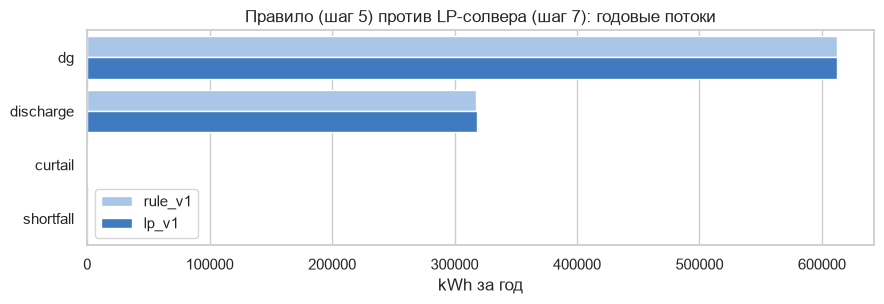

In [8]:
lp = optimize_dispatch(vendor, weather_csv=WEATHER, write_outputs=False)
flows = ("dg", "discharge", "curtail", "shortfall")
cmp_df = pd.DataFrame({
    "поток": [f for f in flows for _ in (0, 1)],
    "модель": ["rule_v1", "lp_v1"] * len(flows),
    "kWh": [m["totals_kwh"][f]
            for f in flows for m in (sim.manifest, lp.manifest)],
})
print(f"солвер: {lp.manifest['solver']} за {lp.manifest['solve_seconds']} c, "
      f"статус {lp.manifest['solver_status']}")
print("Топливо совпало: при плоской цене солярки жадное правило уже оптимально;")
print("LP начнёт выигрывать при ценах, зависящих от времени (спот-рынок).")

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.barplot(data=cmp_df, y="поток", x="kWh", hue="модель",
            palette=[C_BLUE_LIGHT, C_BLUE], ax=ax)
ax.set(title="Правило (шаг 5) против LP-солвера (шаг 7): годовые потоки",
       xlabel="kWh за год", ylabel="")
ax.legend(title="")
plt.tight_layout()

#### 📖 Термины этого блока

- **LP (linear programming)** — минимизация линейной функции при линейных
  ограничениях. Солвер даёт ДОКАЗАННЫЙ глобальный оптимум — не эвристику.
  *Зачем нам:* гарантия «дешевле не существует» вместо «мы не нашли лучше».
- **Переменная решения** — то, что солвер вправе крутить: здесь 6 потоков
  на каждый из 8760 часов (52 560 переменных).
- **Солвер HiGHS** — открытая программа-решатель LP/MILP; статус
  **Optimal** — её сертификат оптимальности; **objective value** —
  значение цели в оптимуме. *Зачем нам:* весь год решается за ~1.5 с.
- **VOLL (value of lost load)** — цена недопоставленного kWh для
  потребителя (у нас $1/kWh — дефолт REopt). *Зачем нам:* превращает
  надёжность в деньги; если VOLL ниже цены солярки, солвер честно
  выключает свет — и это правильная экономика, а не баг.
- **Perfect foresight** — солвер «знает будущее» (весь год погоды и
  нагрузки). *Зачем нам помнить:* реальный контроллер будущего не знает,
  поэтому LP-издержки — нижняя граница, мы измерили разрыв ~0.2% LPSP.

## 8. Главный ответ: оптимальные размеры vs вендор

`optimize_sizing` делает размеры переменными решения (как dvSize в REopt)
и оптимизирует покупку и работу одной LP-задачей. Ограничения: баланс,
SOC-кольцо, крыша 8500 м², надёжность hard. Штуки = ceil(размер/юнит).

штуки: 2932 панелей, 8 шкафов, 5 PCS, 1 генсет
годовые издержки оптимума: $280,504 (вендорская конфигурация: $371,042)


,размер,оптимум,вендор
0,"PV, kWp",1700.0,1500.0
1,"BESS, kWh",1882.3,3132.0
2,"BESS, kW",607.8,1500.0
3,"DG, kW",630.6,1000.0


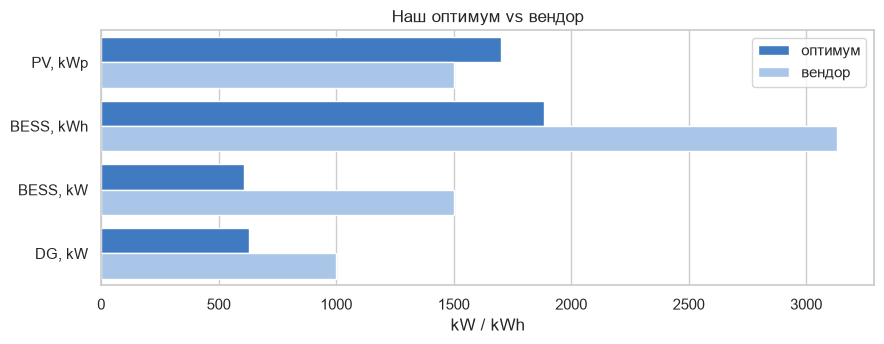

In [9]:
opt = optimize_sizing(sizing_scenario, weather_csv=WEATHER, write_outputs=False)
s, u, m = opt.sizes, opt.units, opt.sim.manifest

print(f"штуки: {u['pv_panels']} панелей, {u['batt_cabinets']} шкафов, "
      f"{u['batt_pcs_units']} PCS, {u['dg_gensets']} генсет")
print(f"годовые издержки оптимума: ${m['objective_value']:,.0f} "
      f"(вендорская конфигурация: ${eco.annual_cost_usd:,.0f})")

cmp_sz = pd.DataFrame({
    "размер": ["PV, kWp", "BESS, kWh", "BESS, kW", "DG, kW"],
    "оптимум": [s["pv_kwp"], s["batt_kwh"], s["batt_kw"], s["dg_kw"]],
    "вендор": [1500.0, 3132.0, 1500.0, 1000.0],
})
melted = cmp_sz.melt(id_vars="размер", var_name="кто", value_name="значение")
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.barplot(data=melted, y="размер", x="значение", hue="кто",
            palette=[C_BLUE, C_BLUE_LIGHT], ax=ax)
ax.set(title="Наш оптимум vs вендор", xlabel="kW / kWh", ylabel="")
ax.legend(title="")
plt.tight_layout()
cmp_sz.round(1)

#### 📖 Термины этого блока

- **Кооптимизация инвестиций и операции** — размеры И почасовая работа
  выбираются одной задачей: «сколько купить, зная, как оно будет работать
  все 8760 часов». Так делают REopt, Calliope, PyPSA. *Зачем нам:* размер
  батареи без годовой симуляции — гадание.
- **Непрерывный сайзинг + штуки** — оптимизатор ищет дробные kW/kWh
  (задача остаётся LP), затем `ceil(размер / юнит)` переводит в целые
  панели/шкафы/генсеты. *Зачем так:* целочисленная задача в лоб — на
  порядки дольше, а разница — доли процента.
- **Политики надёжности**: hard — недопоставка запрещена; lpsp — не выше
  x% спроса; voll — недопоставка просто платная. *Зачем нам:* надёжность —
  не догма, а рычаг с ценником (см. блок 10).
- **Циклический SOC (кольцо)** — запас батареи в конце года «перетекает» в
  его начало (паттерн Calliope, наш дефолт для сайзинга): система не
  получает бесплатную стартовую заправку. *Зачем нам:* честный размер
  батареи; на Йемене поправка — всего +$91/год, вывод устойчив.
- **Интерпретация результата:** батарея вендора переразмерена (~1880 kWh
  экономически против 3132); PV упёрся в крышу; урезанный дизель 631 kW
  опирается на perfect foresight — вендорские 1000 kW как инженерный запас
  оправданы (и генсеты всё равно продаются по 1000 kW).

## 9. Sensitivity: что качает результат (~2 минуты)

Ядро — чистая функция «сценарий → результат», поэтому анализ
чувствительности — цикл: мутируем один параметр → перерешиваем сайзер →
собираем строку таблицы. Свипы: цена дизеля ±50%, CAPEX BESS и PV ±30%.

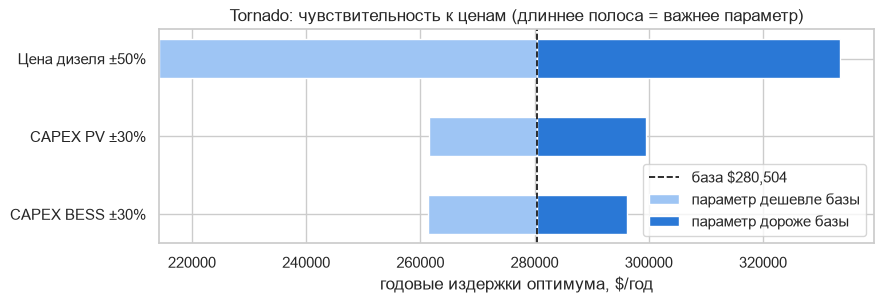

In [10]:
report = run_sensitivity(sizing_scenario, weather_csv=WEATHER, write_outputs=False)
base = float(report.fuel_price.loc[report.fuel_price.value == 1.0,
                                   "annual_cost_usd"].iloc[0])

rows = []
for name, df in (("Цена дизеля ±50%", report.fuel_price),
                 ("CAPEX BESS ±30%", report.bess_capex),
                 ("CAPEX PV ±30%", report.pv_capex)):
    rows.append((name, df.annual_cost_usd.min(), df.annual_cost_usd.max()))
rows.sort(key=lambda r: r[2] - r[1], reverse=True)

fig, ax = plt.subplots(figsize=(9, 3.2))
for i, (name, lo, hi) in enumerate(rows):
    ax.barh(i, base - lo, left=lo, height=0.5, color=C_BLUE_LIGHT,
            label="параметр дешевле базы" if i == 0 else None)
    ax.barh(i, hi - base, left=base, height=0.5, color=C_BLUE,
            label="параметр дороже базы" if i == 0 else None)
ax.axvline(base, color=INK, ls="--", lw=1.2, label=f"база ${base:,.0f}")
ax.set_yticks(range(len(rows)), [r[0] for r in rows])
ax.invert_yaxis()
ax.set(xlabel="годовые издержки оптимума, $/год",
       title="Tornado: чувствительность к ценам (длиннее полоса = важнее параметр)")
ax.legend(loc="lower right")
plt.tight_layout()

#### 📖 Термины этого блока

- **Анализ чувствительности (sensitivity)** — «а что, если параметр
  другой?»: перерешиваем задачу при изменённой цене и смотрим, как плывёт
  ответ. *Зачем нам:* входные цены — прогнозы, и надо знать, какие из них
  опасно прогнозировать плохо.
- **Tornado-график** — полосы «размах результата при колебании одного
  параметра», отсортированные по длине (форма воронки). *Зачем нам:*
  мгновенно видно: цена солярки качает издержки втрое сильнее цен железа —
  уточняй сначала её.
- **База** — оптимум при исходных ценах (пунктир): от неё меряются
  отклонения.

## 10. Pareto: сколько стоит надёжность + стрессы

Каждая точка — отдельная оптимизация с целевым LPSP. «Колено» — точка,
после которой уступки надёжности почти перестают приносить экономию.

Стрессы оптимального дизайна (rule-симулятор, размеры зафиксированы):


,stress,lpsp,shortfall_kwh,dg_kwh,run_id
0,typical_year,0.0018,5102.2593,439150.1653,ad64f57881dc
1,sandstorm_2026-07-10_2026-07-12,0.0025,7123.7746,451451.4873,e2b267bca52a
2,fuel_gap_2026-07-10_2026-07-16,0.0090,25262.9625,418989.4621,b8c52117dcb8


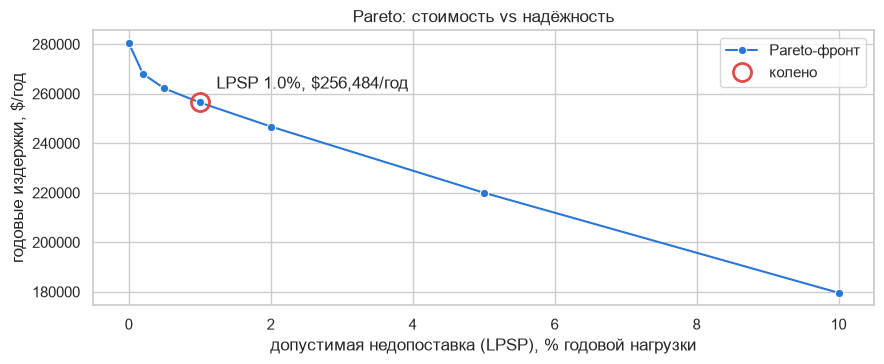

In [11]:
df = report.pareto.sort_values("lpsp_target")
knee = report.knee

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.lineplot(x=df.lpsp_target * 100, y=df.annual_cost_usd,
             marker="o", color=C_BLUE, ax=ax, label="Pareto-фронт")
ax.plot(knee["lpsp"] * 100, knee["annual_cost_usd"], "o", ms=13,
        mfc="none", mec=C_DG, mew=2, label="колено")
ax.annotate(f"LPSP {knee['lpsp']:.1%}, ${knee['annual_cost_usd']:,.0f}/год",
            (knee["lpsp"] * 100, knee["annual_cost_usd"]),
            textcoords="offset points", xytext=(12, 10))
ax.set(xlabel="допустимая недопоставка (LPSP), % годовой нагрузки",
       ylabel="годовые издержки, $/год",
       title="Pareto: стоимость vs надёжность")
ax.legend()
plt.tight_layout()

print("Стрессы оптимального дизайна (rule-симулятор, размеры зафиксированы):")
report.stress.round(4)

#### 📖 Термины этого блока

- **Pareto-фронт** — множество неулучшаемых компромиссов: каждая точка =
  «дешевле при этой надёжности не бывает». Точки ниже фронта невозможны,
  выше — расточительны. *Зачем нам:* превращает спор «сколько девяток
  надёжности покупать» в таблицу с ценами.
- **Колено (knee)** — место излома кривой: до него уступки надёжности
  дёшево окупаются, после — почти нет (ищем точку максимального удаления
  от хорды). *Зачем нам:* готовая рекомендация для переговоров — здесь
  LPSP 1% экономит ~$24k/год против абсолютной надёжности.
- **Стресс-тест** — прогон ВЫБРАННОГО дизайна через плохой сценарий
  (песчаная буря — облучённость 0 на 3 дня; топливный разрыв — дизель
  недоступен неделю). *Зачем нам:* оптимум под типичный год обязан
  деградировать плавно, а не катастрофой — таблица выше это показывает
  (LPSP растёт до долей процента, не до десятков).

## Итоги

1. **Вендорское предложение работоспособно**: LPSP 0, LCOE $0.132/kWh —
   вдвое дешевле чистого дизеля, окупаемость 2.8 года.
2. **Но переплачено за батарею**: экономический размер ~1880 kWh (8
   шкафов), а не 3132 (12). Оптимум экономит ~$91k в год (24%).
3. **Дизель — главный фактор риска**: его цена качает издержки втрое
   сильнее цен железа. Прогноз цены солярки важнее торга за панели.
4. **Колено Pareto — LPSP 1%**: согласие на ~87 часов недопоставки в год
   экономит ещё ~$24k/год.

---
*Оговорка: модель — инструмент понимания и проверки вендора, НЕ замена
лицензированному инженеру для финального проектирования.*